# 01 — Perception Control

> **"Visualization is not about showing data. It is about controlling what the viewer sees first."**

---

Bộ não con người không đọc chart một cách bình đẳng.
Nó bị thu hút bởi màu sắc nổi bật, độ tương phản cao, và vị trí nổi bật hơn.

**Perception Control** là kỹ thuật dùng các thuộc tính thị giác (màu sắc, độ mờ, độ dày, thứ tự lớp)
để chủ động điều hướng ánh nhìn của người xem đến đúng nơi cần quan tâm.

### Nội dung notebook này:

1. **Signal vs Noise** — Tách tín hiệu ra khỏi nhiễu
2. **Highlight** — Làm nổi bật series / điểm / vùng quan trọng
3. **Fade** — Đẩy nền xuống background
4. **Focus** — Thu hẹp sự chú ý vào một khoảng thời gian
5. **Visual Hierarchy** — Phân cấp thị giác: primary / secondary / background
6. **Saliency** — Encode mức độ quan trọng bằng kích thước và màu
7. **Outlier Emphasis** — Làm nổi bật điểm dị thường

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')   # đổi thành 'inline' nếu dùng Jupyter classic
%matplotlib inline

# --- vizint imports ---
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.perception import (
    highlight_series, highlight_region, highlight_points,
    fade_series, fade_background_lines,saliency_map_scatter,
)
from vizint.annotation import label_last_point, add_note

np.random.seed(42)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo dữ liệu giả lập: 5 series đại diện cho 5 công ty trong cùng ngành.
Một trong số đó là **signal** (công ty chúng ta quan tâm), 4 còn lại là **noise** (background context).

In [2]:
T = 60  # 60 tháng = 5 năm
t = np.arange(T)

# 4 background companies — random walks
bg_series = {
    'Company B': 100 + np.cumsum(np.random.randn(T) * 1.5),
    'Company C': 100 + np.cumsum(np.random.randn(T) * 1.8),
    'Company D': 100 + np.cumsum(np.random.randn(T) * 1.2),
    'Company E': 100 + np.cumsum(np.random.randn(T) * 1.6),
}

# Signal company — grows faster, then drops, then recovers
trend     = 0.5 * t
shock     = np.where(t >= 40, -20, 0)
recovery  = np.where(t >= 48, 1.2 * (t - 48), 0)
noise_sig = np.random.randn(T) * 1.0
y_signal  = 100 + trend + shock + recovery + noise_sig

print(f'Time steps : {T}')
print(f'Signal range: [{y_signal.min():.1f}, {y_signal.max():.1f}]')
print(f'Background series: {list(bg_series.keys())}')

Time steps : 60
Signal range: [99.2, 123.3]
Background series: ['Company B', 'Company C', 'Company D', 'Company E']


---
## 1. Signal vs Noise

**Vấn đề:** Khi plot tất cả series với style giống nhau, người xem không biết nhìn vào đâu.

**Giải pháp:** Dùng `highlight_series` cho signal và `fade_series` cho noise.
Contrast giữa hai lớp này buộc mắt người xem đi thẳng vào đường nổi bật.

C:\Users\Duy\AppData\Local\Temp\ipykernel_12472\1214386301.py:13: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
Y:\Yui\From-data-to-story\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


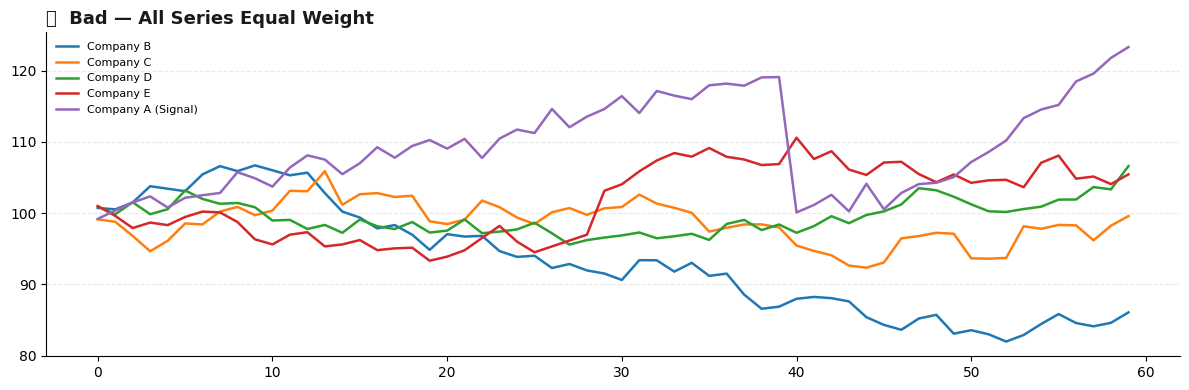

In [3]:
# ── BAD: tất cả series đều như nhau ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')

for name, y in bg_series.items():
    ax.plot(t, y, linewidth=1.8, label=name)
ax.plot(t, y_signal, linewidth=1.8, label='Company A (Signal)')

ax.legend(frameon=False, fontsize=8)
ax.set_title('❌  Bad — All Series Equal Weight', loc='left',
             fontsize=13, fontweight='bold', color='#1a1a1a')
despine(ax)
set_grid(ax)
plt.tight_layout()
plt.show()

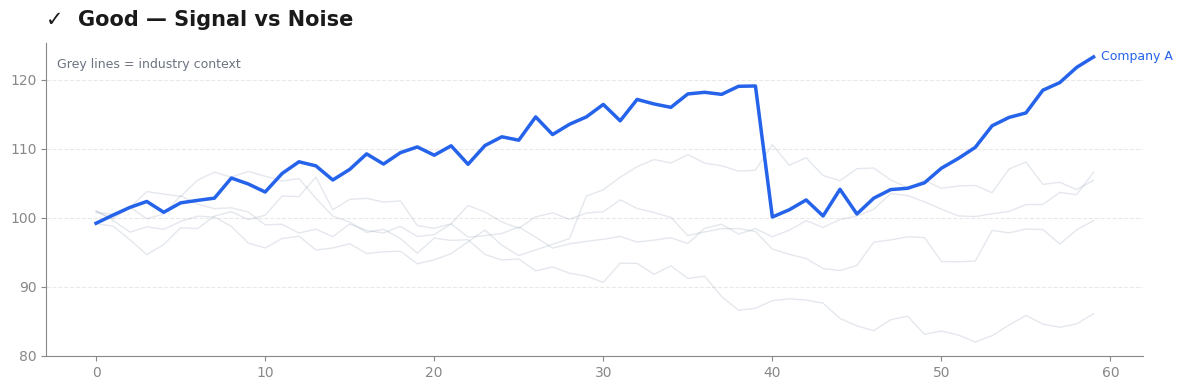

In [4]:
# ── GOOD: signal nổi, noise mờ ──────────────────────────────────────────────
chart = ChartBuilder(figsize=(12, 4)).set_title('✓  Good — Signal vs Noise').build()
ax = chart.ax

# Noise — faded background
for name, y in bg_series.items():
    fade_series(ax, t, y, color='#94A3B8', alpha=0.25, linewidth=1.0)

# Signal — highlighted
highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.5)
label_last_point(ax, t, y_signal, text='Company A', color='#2563EB')

add_note(ax, 'Grey lines = industry context', x=0.01, y=0.95)
plt.tight_layout()
plt.show()

---
## 2. Highlight — Series / Points / Region

**`highlight_series`** — làm nổi một đường (màu đậm, nét dày, z-order cao).

**`highlight_points`** — đánh dấu một tập điểm cụ thể bằng scatter markers.

**`highlight_region`** — tô màu một khoảng trên trục x để thu hút sự chú ý vào giai đoạn đó.

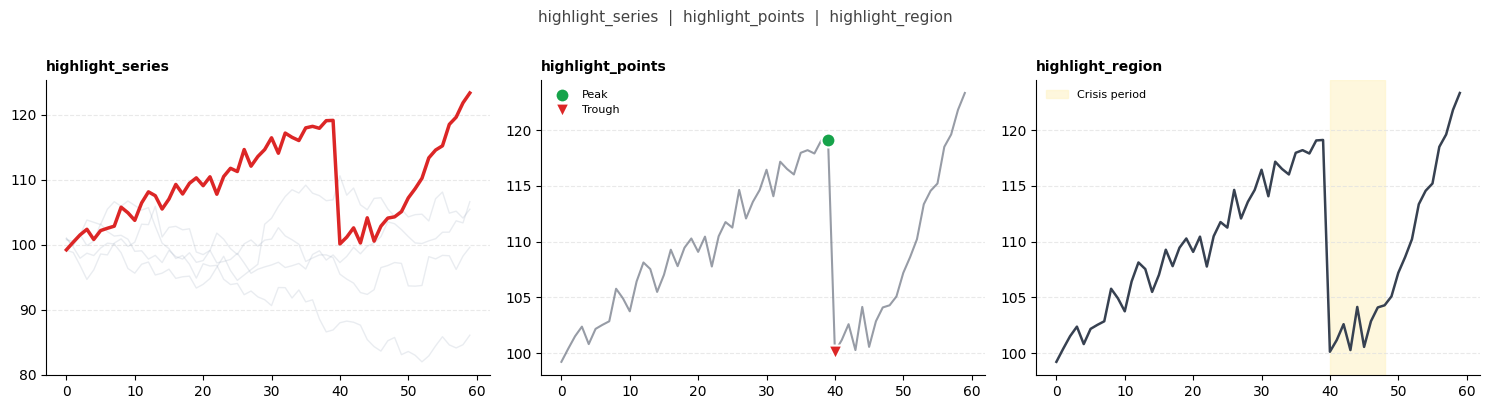

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
fig.suptitle('highlight_series  |  highlight_points  |  highlight_region',
             fontsize=11, color='#444444', y=1.01)

# Panel 1 — highlight_series
ax = axes[0]
for name, y in bg_series.items():
    fade_series(ax, t, y, alpha=0.2)
highlight_series(ax, t, y_signal, color='#DC2626', linewidth=2.5)
ax.set_title('highlight_series', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2 — highlight_points (đỉnh và đáy)
ax = axes[1]
ax.plot(t, y_signal, color='#6B7280', linewidth=1.5, alpha=0.7)
# Đỉnh: tháng 39, Đáy: tháng 43
peak_idx  = np.argmax(y_signal[:45])
trough_idx = 40 + np.argmin(y_signal[40:50])
highlight_points(ax, [t[peak_idx]], [y_signal[peak_idx]],
                 color='#16A34A', size=100, label='Peak')
highlight_points(ax, [t[trough_idx]], [y_signal[trough_idx]],
                 color='#DC2626', size=100, marker='v', label='Trough')
ax.legend(frameon=False, fontsize=8)
ax.set_title('highlight_points', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 3 — highlight_region
ax = axes[2]
ax.plot(t, y_signal, color='#374151', linewidth=1.8)
highlight_region(ax, xmin=40, xmax=48, color='#FEF3C7', alpha=0.6, label='Crisis period')
ax.legend(frameon=False, fontsize=8)
ax.set_title('highlight_region', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 3. Fade — Push to Background

Hai cách fade:

- **`fade_series`** — vẽ trực tiếp với alpha thấp (dùng khi vẽ mới).
- **`fade_background_lines`** — áp dụng lên các lines *đã có sẵn* trong axes (dùng khi cần retroactively làm mờ).

Sau khi fade toàn bộ, vẽ signal lên trên — tạo hiệu ứng **focus-on-one**.

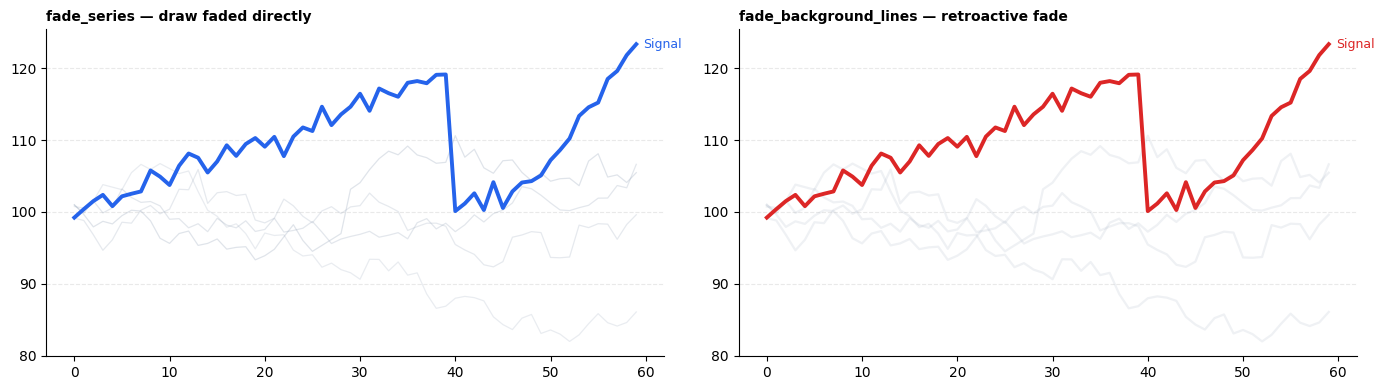

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: fade_series khi vẽ
ax = axes[0]
for i, (name, y) in enumerate(bg_series.items()):
    fade_series(ax, t, y, color='#94A3B8', alpha=0.2 + i * 0.03, linewidth=0.9)
highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.8)
label_last_point(ax, t, y_signal, text='Signal', color='#2563EB')
ax.set_title('fade_series — draw faded directly', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2: vẽ tất cả trước, fade retroactively, rồi highlight lại
ax = axes[1]
all_series = {**bg_series, 'Company A': y_signal}
colors_all = ['#94A3B8', '#6B7280', '#9CA3AF', '#CBD5E1', '#2563EB']
for (name, y), c in zip(all_series.items(), colors_all):
    ax.plot(t, y, color=c, linewidth=1.6, label=name)

# Fade tất cả, sau đó re-highlight đường cuối (Company A)
fade_background_lines(ax, alpha=0.15, color='#94A3B8')
highlight_series(ax, t, y_signal, color='#DC2626', linewidth=2.8)
label_last_point(ax, t, y_signal, text='Signal', color='#DC2626')
ax.set_title('fade_background_lines — retroactive fade', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 4. Focus-and-Context

Khi muốn người xem chú ý vào **một giai đoạn cụ thể** nhưng vẫn giữ toàn bộ context:

- **`focus_on_range`** — tô sáng vùng focus bằng background màu nhạt + đường border dọc.
- **`blur_outside_range`** — overlay màu trắng mờ lên phần ngoài vùng focus, giảm độ nổi của nó.

Hai hàm này kết hợp tạo hiệu ứng **spotlight** trên chart.

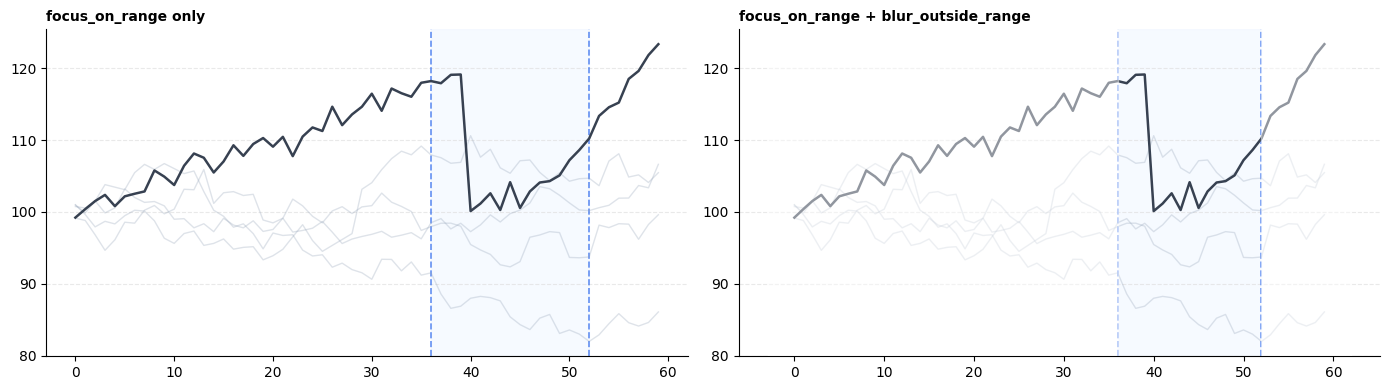

In [7]:
from vizint.perception.focus import focus_on_range, blur_outside_range

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

FOCUS_START, FOCUS_END = 36, 52   # giai đoạn crisis + recovery

for ax, title, use_blur in zip(
    axes,
    ['focus_on_range only', 'focus_on_range + blur_outside_range'],
    [False, True]
):
    for name, y in bg_series.items():
        ax.plot(t, y, color='#94A3B8', linewidth=1.0, alpha=0.3)
    ax.plot(t, y_signal, color='#374151', linewidth=1.8)

    # Focus region
    focus_on_range(ax, FOCUS_START, FOCUS_END,
                   highlight_color='#EFF6FF', alpha=0.5,
                   border_color='#2563EB', border_linewidth=1.2)

    if use_blur:
        blur_outside_range(ax, FOCUS_START, FOCUS_END,
                           blur_alpha=0.45)

    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 5. Visual Hierarchy

**Visual Hierarchy** là việc phân cấp rõ ràng các lớp thông tin trong một chart:

| Level | Alpha | Linewidth | Z-order | Mục đích |
|-------|-------|-----------|---------|----------|
| `primary` | 1.0 | ×1.5 | 5 | Insight chính |
| `secondary` | 0.65 | ×1.0 | 3 | Thông tin hỗ trợ |
| `background` | 0.25 | ×0.7 | 1 | Context |

`emphasize_series(ax, keep_index=N)` — tự động set primary cho line thứ N, background cho tất cả còn lại.

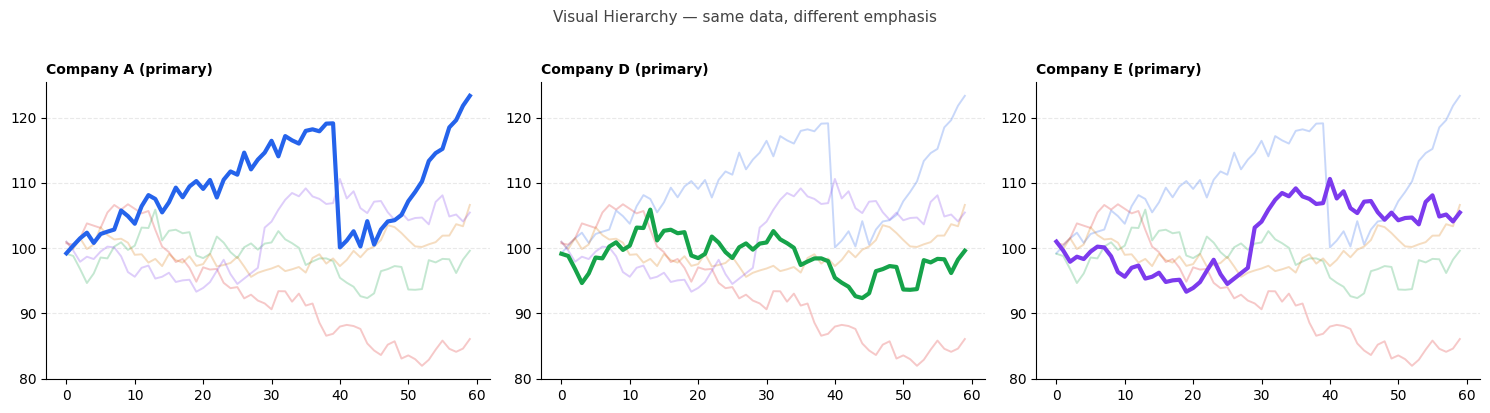

In [8]:
from vizint.styling.hierarchy import emphasize_series, set_emphasis

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='white')
colors = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']

all_y = [y_signal] + list(bg_series.values())
all_names = ['Company A'] + list(bg_series.keys())

for ax_idx, (ax, focus_i, focus_name) in enumerate(zip(
    axes,
    [0, 2, 4],
    ['Company A (primary)', 'Company D (primary)', 'Company E (primary)']
)):
    # Vẽ tất cả
    for i, (name, y, c) in enumerate(zip(all_names, all_y, colors)):
        ax.plot(t, y, color=c, linewidth=2.0, label=name)

    # Phân cấp: focus_i là primary, còn lại là background
    emphasize_series(ax, keep_index=focus_i,
                     level_keep='primary', level_rest='background')

    ax.set_title(focus_name, loc='left', fontsize=10, fontweight='bold')
    despine(ax); set_grid(ax)

fig.suptitle('Visual Hierarchy — same data, different emphasis',
             fontsize=11, color='#444', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Saliency Encoding

**Saliency** = mức độ quan trọng của từng điểm dữ liệu.

Hàm `saliency_map_scatter` encode saliency bằng **2 kênh thị giác cùng lúc**:
- **Màu sắc** (colormap YlOrRd: vàng → đỏ)
- **Kích thước** marker

Dùng 2 kênh cùng lúc giúp saliency cao **nổi bật gấp đôi** so với dùng 1 kênh.

C:\Users\Duy\AppData\Local\Temp\ipykernel_12472\2439763242.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


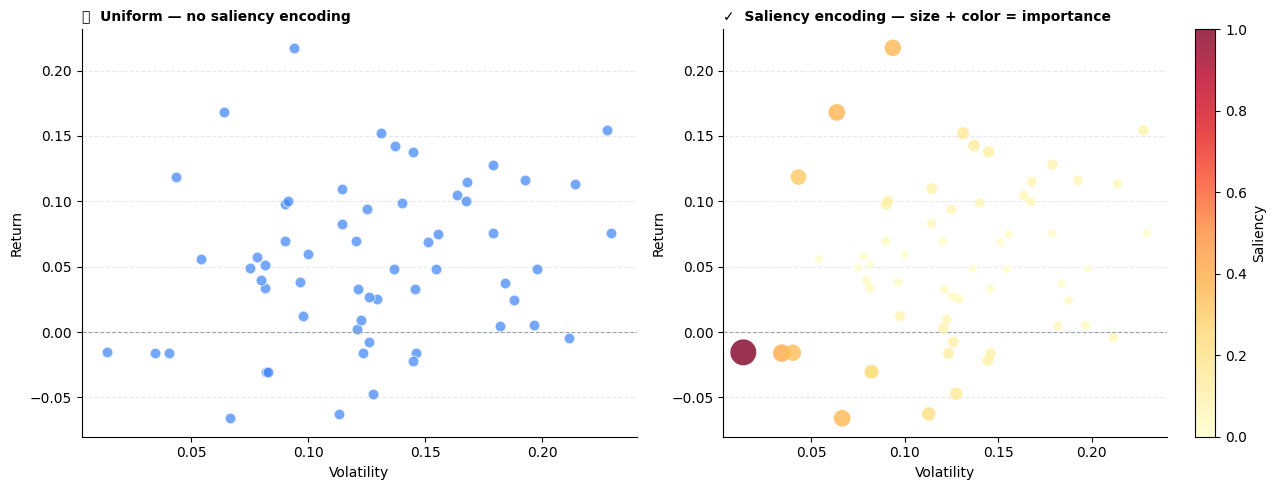

In [9]:
# Tạo scatter data — 2D portfolio returns
n_assets = 60
returns   = np.random.randn(n_assets) * 0.08 + 0.05
volatility = np.abs(np.random.randn(n_assets) * 0.05 + 0.12)

# Saliency = |return - mean| / volatility  (risk-adjusted deviation)
saliency = np.abs(returns - returns.mean()) / volatility

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Panel 1: uniform scatter — không saliency
ax = axes[0]
ax.scatter(volatility, returns, color='#3B82F6', s=60, alpha=0.7, edgecolors='white', linewidths=0.8)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatility'); ax.set_ylabel('Return')
ax.set_title('❌  Uniform — no saliency encoding', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2: saliency encoding
ax = axes[1]
saliency_map_scatter(ax, volatility, returns, saliency,
                     cmap='YlOrRd', size_range=(30, 350),
                     alpha=0.8, colorbar=True)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--')
ax.set_xlabel('Volatility'); ax.set_ylabel('Return')
ax.set_title('✓  Saliency encoding — size + color = importance', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 7. Outlier Detection & Emphasis

Outlier có thể là **lỗi dữ liệu** hoặc **sự kiện quan trọng** — cả hai đều cần được nhìn thấy.

`detect_and_mark_outliers` hỗ trợ 2 phương pháp:
- **`'iqr'`** (Tukey) — dùng IQR × threshold làm ngưỡng. Phù hợp với data có phân phối skewed.
- **`'zscore'`** — dùng số độ lệch chuẩn. Phù hợp với data gần normal distribution.

`emphasize_outliers` thêm một vòng tròn mờ xung quanh outlier — giữ marker gốc nhưng tăng saliency.

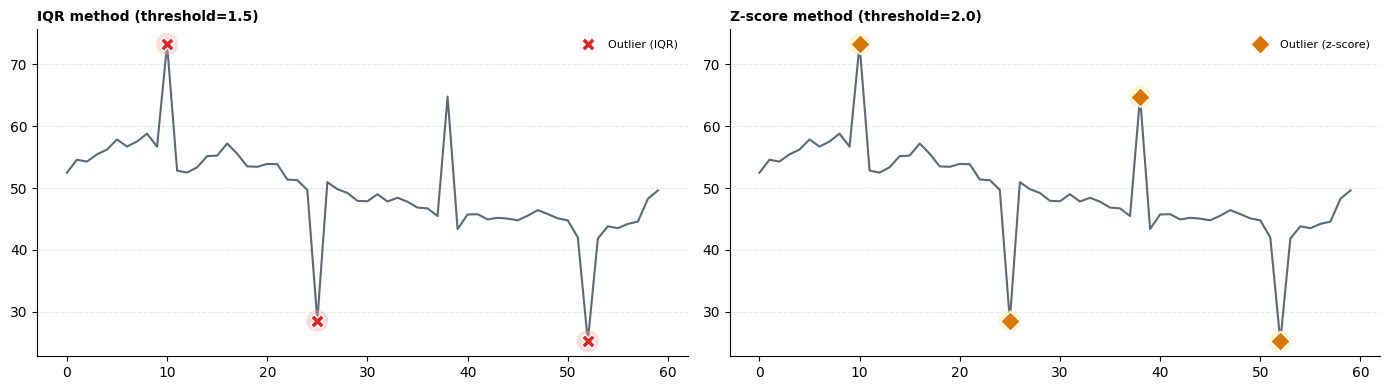

In [10]:
from vizint.perception.outlier import detect_and_mark_outliers, emphasize_outliers

# Tạo series với outlier nhân tạo
y_clean   = 50 + np.cumsum(np.random.randn(T) * 1.2)
y_with_ol = y_clean.copy()
outlier_idx = [10, 25, 38, 52]   # inject outliers
y_with_ol[outlier_idx] += np.array([18, -22, 20, -15])

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: IQR method
ax = axes[0]
ax.plot(t, y_with_ol, color='#374151', linewidth=1.5, alpha=0.8)
emphasize_outliers(ax, t, y_with_ol, method='iqr', threshold=1.5, ring_color='#FCA5A5')
detect_and_mark_outliers(ax, t, y_with_ol, method='iqr', threshold=1.5,
                         marker_color='#DC2626', label='Outlier (IQR)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('IQR method (threshold=1.5)', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

# Panel 2: Z-score method
ax = axes[1]
ax.plot(t, y_with_ol, color='#374151', linewidth=1.5, alpha=0.8)
emphasize_outliers(ax, t, y_with_ol, method='zscore', threshold=2.0, ring_color='#FDE68A')
detect_and_mark_outliers(ax, t, y_with_ol, method='zscore', threshold=2.0,
                         marker_color='#D97706', marker='D', label='Outlier (z-score)')
ax.legend(frameon=False, fontsize=8)
ax.set_title('Z-score method (threshold=2.0)', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

---
## 8. Putting It All Together — Full Perception Stack

Kết hợp toàn bộ kỹ thuật perception trong một chart duy nhất:

1. **Fade** noise series xuống background
2. **Highlight** signal series
3. **Focus** vào giai đoạn quan trọng
4. **Mark** turning points (đỉnh + đáy)
5. **Label** điểm cuối
6. **Apply theme** để hoàn thiện styling

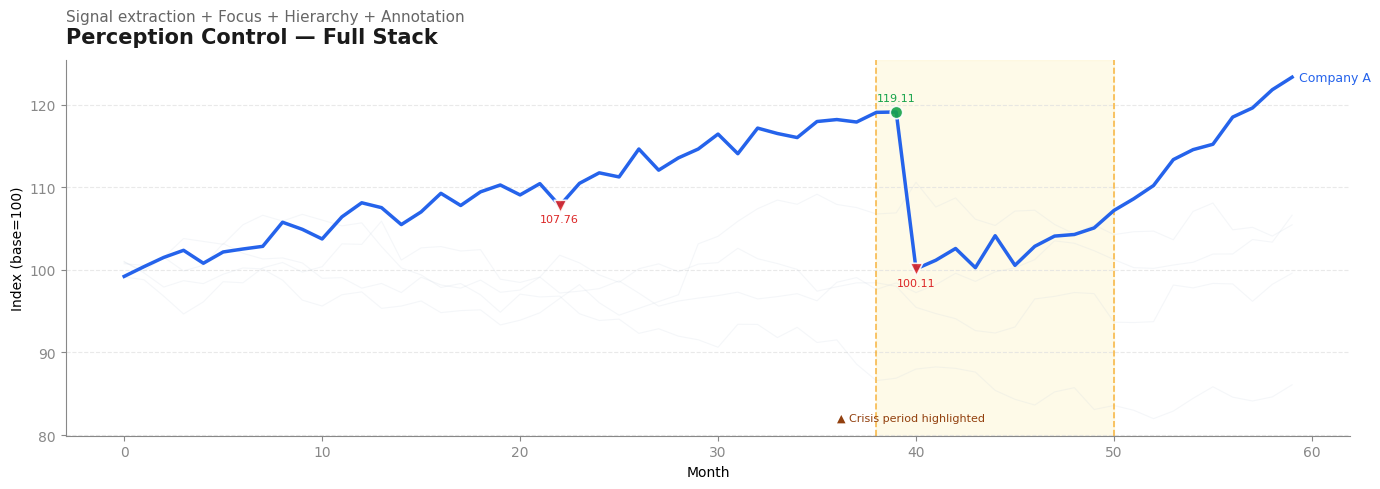

In [11]:
from vizint.narrative.turning_point import mark_turning_points
from vizint.annotation import add_note, add_caption

chart = (
    ChartBuilder(figsize=(14, 5))
    .set_title('Perception Control — Full Stack')
    .set_subtitle('Signal extraction + Focus + Hierarchy + Annotation')
    .build()
)
ax = chart.ax

# Layer 1: Noise
for name, y in bg_series.items():
    fade_series(ax, t, y, color='#CBD5E1', alpha=0.2, linewidth=0.8)

# Layer 2: Signal
highlight_series(ax, t, y_signal, color='#2563EB', linewidth=2.5, label='Company A')

# Layer 3: Focus period (crisis window)
focus_on_range(ax, 38, 50, highlight_color='#FEF3C7', alpha=0.4,
               border_color='#F59E0B', border_linewidth=1.2)

# Layer 4: Turning points
mark_turning_points(ax, t, y_signal, order=4,
                    max_color='#16A34A', min_color='#DC2626', show_labels=True)

# Layer 5: Label
label_last_point(ax, t, y_signal, text='Company A', color='#2563EB')

# Annotation
add_note(ax, '▲ Crisis period highlighted', x=0.60, y=0.06,
         color='#92400E', fontsize=8)

ax.set_xlabel('Month')
ax.set_ylabel('Index (base=100)')

plt.tight_layout()
plt.show()

---
## Summary

| Technique | Function | Mục đích |
|-----------|----------|----------|
| Signal vs Noise | `highlight_series` + `fade_series` | Tách tín hiệu khỏi nhiễu |
| Point emphasis | `highlight_points` | Đánh dấu điểm dữ liệu cụ thể |
| Region emphasis | `highlight_region` | Thu hút vào giai đoạn cụ thể |
| Retroactive fade | `fade_background_lines` | Làm mờ lines đã có sẵn |
| Spotlight | `focus_on_range` + `blur_outside_range` | Hiệu ứng spotlight |
| Hierarchy | `emphasize_series` | Phân cấp primary / secondary / bg |
| Importance encoding | `saliency_map_scatter` | Encode importance = size + color |
| Anomaly detection | `detect_and_mark_outliers` | IQR hoặc z-score outlier detection |

---

### Key Takeaway

> Một chart tốt không phải là chart có đủ thông tin.
> Một chart tốt là chart **kiểm soát được thứ tự** mà người xem nhận thức thông tin.

**Next →** `02_narrative_visualization.ipynb` — Khi nào mọi thứ thay đổi: turning points, events, và story framing.